# **Lab 2 – Tidying, Cleaning, Imputation, and Outlier Detection**

## Machine Learning Programming

This assignment continues the work started in **`week5Lab.ipynb`**.  
Open this notebook and complete the activities **in this notebook**, preserving the section order and the overall structure.

The purpose of this lab is to practice the data-preprocessing work that normally takes place before machine learning: reshaping data, cleaning inconsistent values, handling missing data, detecting outliers, visualizing results, and explaining the decisions you make.

## **Assignment Overview**

### Purpose
By the end of this lab, you should be able to take several imperfect datasets and make them more suitable for analysis and later machine-learning work.

### Learning Outcomes
You will practice how to:

- inspect the shape, columns, data types, and quality of a dataset;
- distinguish **wide** and **long/tidy** data;
- reshape data with `pd.melt()` or `DataFrame.melt()`;
- clean strings using Pandas string methods;
- identify, quantify, drop, and impute missing values;
- compare mean, median, mode, and `SimpleImputer` approaches;
- identify outliers visually with box plots and scatter plots;
- identify outliers statistically using **Z-Scores** and **IQR**;
- justify preprocessing decisions using evidence from the data;
- document a reproducible Python data-processing workflow.

### Estimated Completion Time
Approximately **2.5–3.5 hours**, depending on your Python experience.

## **Submission and Project Structure**

Keep the project organized so another person can reproduce your work.

Recommended structure:

```text
project/
├── week5Lab.ipynb
├── README.md
├── requirements.txt
├── .gitignore
└── data/
    ├── pew-raw.csv
    ├── billboard.csv
    ├── cars.csv
    └── diabetes.csv
```

A clearly named equivalent data folder such as `CSVs/` or `datasets/` is also acceptable if all notebook paths are updated consistently.

### Required submission artifacts

- `week5Lab.ipynb` containing **all four completed sections**
- `README.md` with at least 1–2 meaningful sentences describing the lab and how to run it
- `requirements.txt` containing the packages required to reproduce the environment
- `.gitignore`
- all required data files inside a clearly named data folder

**Important:** Use relative paths such as `./data/cars.csv`. Do not use absolute paths from your own computer.

**Environment practice:** Use `requirements.txt` to define the environment. Do not add `!pip install ...` cells to the notebook when a requirements file is provided.

## **Before You Begin**

Use the following libraries where appropriate:

- `pandas`
- `numpy`
- `matplotlib`
- `seaborn`
- `scikit-learn`

Run the import cell below before beginning the exercises.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer

# Optional display settings
pd.set_option("display.max_columns", None)

## **General Expectations**

For every section:

1. Write the required Python code.
2. Display enough output to demonstrate that the code works.
3. Add short Markdown explanations in your own words.
4. Label plots clearly with a title and axis labels.
5. Explain what the output means instead of only producing it.
6. Preserve the required section headings so the notebook is easy to follow.
7. Before submitting, restart the kernel and use **Run All** to confirm the notebook executes from beginning to end.

# **Section 1 – PEW Research Dataset**

## **Learning Topic: Data Tidying and Reshaping**

A dataset is commonly described as **tidy** when:

1. each variable forms a column;
2. each observation forms a row; and
3. each type of observational unit forms a table.

The PEW dataset represents counts for religions across income ranges. In its original form, income values appear as column headings. You will reshape the dataset from **wide** format to **long/tidy** format using `melt()`.

### Required concepts
- dataset inspection
- wide versus long data
- identifier variables
- measured variables
- `pd.melt()` or `DataFrame.melt()`
- visualization after reshaping

## **Getting the PEW Dataset from the Internet**

For this lab, use the small **PEW religion-and-income dataset** commonly used to demonstrate tidy-data principles. This is the dataset whose first column is `religion` and whose remaining columns are income ranges such as `<$10k`, `$10-20k`, and `$20-30k`.

### Recommended method — download in your browser

1. Open the dataset in a browser:
   `https://raw.githubusercontent.com/nickhould/tidy-data-python/master/data/pew-raw.csv`
2. Save the file as **`pew-raw.csv`**.
3. Create a folder named **`data`** in the same project folder as this notebook if it does not already exist.
4. Move `pew-raw.csv` into the `data` folder.
5. Confirm that your project contains:

```text
project/
├── week5Lab.ipynb
└── data/
    └── pew-raw.csv
```

6. Load the local copy with:

```python
df_pew = pd.read_csv("./data/pew-raw.csv")
```

### Optional Python-assisted download

The following is an example only. You may use it once to obtain the dataset, but your submitted analysis should subsequently read the **local copy** from `./data/`.

```python
from pathlib import Path
import pandas as pd

Path("data").mkdir(exist_ok=True)

url = "https://raw.githubusercontent.com/nickhould/tidy-data-python/master/data/pew-raw.csv"
df_pew = pd.read_csv(url)
df_pew.to_csv("./data/pew-raw.csv", index=False)
```

### Verify before continuing

After loading the file, check that the dataframe contains a `religion` column and multiple income-range columns. If it does not, stop and verify that you downloaded the correct dataset.

> **Good reproducibility practice:** Do not depend on the Internet every time the notebook runs. Download the dataset once, store it in the project's `data/` folder, commit the permitted data file to your repository, and use a relative path in the notebook.

### **Task 1.1 – Load and Inspect the Dataset**

1. Load the PEW dataset from your data folder.
2. Display its shape.
3. Display its column names.
4. Display several rows using `head()`, `loc`, `iloc`, or `tail()`.
5. Identify the column that should remain the identifier variable.

In [ ]:
# TODO: Load the PEW dataset using a RELATIVE path.
# Example:
df_pew = pd.read_csv("./data/pew-raw.csv")

# TODO: Display shape, columns, and several rows.
print(df_pew.shape)
print(df_pew.columns)
print(df_pew.head())

# religion shoud be the identifier variable.
df_pew.set_index("religion", inplace=True)

(10, 7)
Index(['religion', ' <$10k', ' $10-20k', '$20-30k', '$30-40k', ' $40-50k',
       '$50-75k'],
      dtype='str')
            religion   <$10k   $10-20k  $20-30k  $30-40k   $40-50k  $50-75k
0           Agnostic      27        34       60       81        76      137
1            Atheist      12        27       37       52        35       70
2           Buddhist      27        21       30       34        33       58
3           Catholic     418       617      732      670       638     1116
4  Dont know/refused      15        14       15       11        10       35


### **Task 1.2 – Explain the Problem**

In a Markdown cell below, answer:

- What is not tidy about the original PEW dataset?
- Which values are stored in column names?
- Which column should be treated as the identifier (`id_vars`)?

> **TODO – Your explanation:**  
> Write your answer here.

"A dataset is commonly described as **tidy** when:
[...]
2. each observation forms a row; and
3. each type of observational unit forms a table."

The dataset has multiple observations in a single row. (money from several range columns in one row)
Thus rule 2 is not fulfilled, and by extension neither is 3.

Religion, and ranges of unspecified money/dollar values by ranges of 10k are in the columns.
Religion should be the identifier, as it is the most unique variable and appears to group the other money range variables.

### **Task 1.3 – Reshape with `melt()`**

Use either of these valid Pandas forms:

```python
pd.melt(...)
```

or

```python
df.melt(...)
```

Your result should have meaningful names for the new variable and value columns, such as `income` and `count`.

In [ ]:
# TODO: Reshape the PEW dataframe from wide to long format with melt().
df_pew_long = df_pew.melt(id_vars="religion", var_name="income", value_name="count", ignore_index=False)
# TODO: Display the first rows of the reshaped dataframe.
print(df_pew_long.head(11))

# TODO: Compare the original and reshaped shapes.
print("Original shape:", df_pew.shape)
print("Reshaped shape:", df_pew_long.shape)

                   religion    income  count
0                  Agnostic     <$10k     27
1                   Atheist     <$10k     12
2                  Buddhist     <$10k     27
3                  Catholic     <$10k    418
4         Dont know/refused     <$10k     15
5         Evangelical Prot      <$10k    575
6                    Hindu      <$10k      1
7  Historically Black Prot      <$10k    228
8         Jehovahs Witness      <$10k     20
9                   Jewish      <$10k     19
0                  Agnostic   $10-20k     34
Original shape: (10, 7)
Reshaped shape: (60, 3)


### **Task 1.4 – Visualize the Tidy Data**

Create at least **one meaningful visualization** from the reshaped dataset.

Possible questions include:

- How do counts differ across income groups?
- How do selected religions compare across income groups?

Your plot must include a title and axis labels.

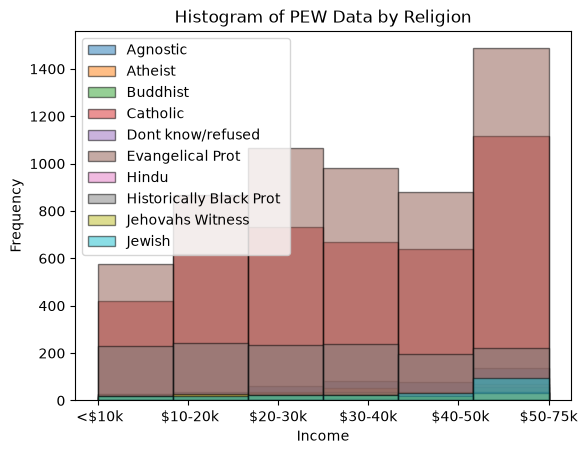

In [9]:
# TODO: Create a visualization using the reshaped PEW data.
# use matplotlib to create a histogram. group by religion, y axis is frequency, x axis is income.
import matplotlib.pyplot as plt

for religion, group in df_pew_long.groupby("religion"):
    plt.hist(group["income"], weights=group["count"], bins=len(group["income"].unique()), edgecolor="black", alpha=0.5, label=religion)

plt.xlabel("Income")
plt.ylabel("Frequency")
plt.title("Histogram of PEW Data by Religion")
plt.legend()
plt.show()


### **Task 1.5 – PEW Reflection**

Answer **all** questions briefly in your own words:

1. What was the main structural problem with the original dataset?
2. What does `id_vars` mean in `melt()`?
3. What information moved from columns into rows?
4. How did the number of rows change after reshaping, and why?
5. Why is the long format easier to analyze or visualize?
6. What did your visualization reveal?

> **TODO – PEW observations and reflection:**  
> Write your answers here.

The main structural problem is that the data was not tidy. Several observations of frequency of ranges of income were located in single rows of the table. 

id_vars is the identifier variable. Setting this in melt() groups every observation by whatever value was in that column originally.

All the frequencies of ranges of incomes (count) were moved to rows.

The number of rows went from 10 to 60, not including the column headers. This is because there were 7 columns, and they were melted to 3 columns. One column was retained as the identifier. A new column was created to classify by varaible. The last column contained the count, and there were 60 observations of count, which resulted post-melt() into 60 rows.


# **Section 2 – Billboard Dataset**

## **Learning Topic: Advanced Data Tidying**

The Billboard dataset stores weekly song rankings across many week columns. You will reshape those columns into rows, clean the resulting week labels, convert ranking values to appropriate data types, handle missing values, and analyze ranking trends.

### Required concepts
- `pd.melt()` or `DataFrame.melt()`
- Pandas string methods such as:
  - `.str.replace()`
  - `.str.strip()`
  - `.str.extract()`
  - `.str.upper()`
  - `.str.lower()`
- numeric conversion
- missing-value handling
- dates / timedeltas where appropriate

## **Getting the Billboard Dataset from the Internet**

Use the **Billboard weekly ranking dataset** associated with the classic tidy-data example. The correct file contains song information plus many weekly ranking columns such as `1st week`, `2nd week`, etc. (column names can vary slightly between copies).

### Recommended method — download in your browser

1. Open this public copy of `billboard.csv`:
   `https://gist.githubusercontent.com/AdrianLl/bd94c12f2b3c3a899c4ca13d0a548966/raw/billboard.csv`
2. Save the file as **`billboard.csv`**.
3. Place it inside your project's **`data`** folder.
4. Your project should now include:

```text
project/
├── week5Lab.ipynb
└── data/
    ├── pew-raw.csv
    └── billboard.csv
```

5. Load the local file. If ordinary UTF-8 decoding fails, try `encoding="unicode_escape"`:

```python
billboard = pd.read_csv("./data/billboard.csv", encoding="unicode_escape")
```

### Optional Python-assisted download

```python
from pathlib import Path
import pandas as pd

Path("data").mkdir(exist_ok=True)

url = "https://gist.githubusercontent.com/AdrianLl/bd94c12f2b3c3a899c4ca13d0a548966/raw/billboard.csv"
billboard = pd.read_csv(url, encoding="unicode_escape")
billboard.to_csv("./data/billboard.csv", index=False)
```

### Verify before continuing

Inspect `billboard.columns`. You should see identifying information for songs/artists and a sequence of weekly ranking columns. Those repeated week columns are the columns you will later reshape with `melt()`.

> **Important:** Different online copies sometimes use slightly different column names. Do not blindly copy column names from an example. Inspect **your downloaded file** first and adapt your code accordingly.

### **Task 2.1 – Load and Inspect Billboard Data**

1. Load the Billboard dataset.
2. If normal UTF-8 decoding fails, try `encoding="unicode_escape"`.
3. Display its shape, columns, and first rows.
4. Identify the columns that represent weekly rankings.

In [ ]:
# TODO: Load the Billboard dataset from your data folder.
# Example:
billboard = pd.read_csv("./data/billboard.csv", encoding="unicode_escape")

# TODO: Inspect shape, columns, data types, and first rows.
print(billboard.shape)
print(billboard.columns)
print(billboard.dtypes)
print(billboard.head(10))

#column 12 to 64 (base 0) are the weekly rankings.

(317, 77)
Index(['artist', 'track', 'duration', 'genre', 'date entered', 'date peaked',
       'weeks to peak', 'weeks on chart', 'worst position', 'best position',
       'enter rank', 'exit rank', '1st week', '2nd week', '3rd week',
       '4th week', '5th week', '6th week', '7th week', '8th week', '9th week',
       '10th week', '11th week', '12th week', '13th week', '14th week',
       '15th week', '16th week', '17th week', '18th week', '19th week',
       '20th week', '21st week', '22nd week', '23rd week', '24th week',
       '25th week', '26th week', '27th week', '28th week', '29th week',
       '30th week', '31st week', '32nd week', '33rd week', '34th week',
       '35th week', '36th week', '37th week', '38th week', '39th week',
       '40th week', '41st week', '42nd week', '43rd week', '44th week',
       '45th week', '46th week', '47th week', '48th week', '49th week',
       '50th week', '51st week', '52nd week', '53rd week', '54th week',
       '55th week', '56th week', '57th

### **Task 2.2 – Diagnose the Tidiness Problem**

Explain why having columns such as week 1, week 2, week 3, etc. makes the dataset difficult to analyze.

Identify:

- identifier columns;
- weekly measured columns; and
- the variables you want after reshaping.

> **TODO – Your explanation:**  
> Write your answer here.

A dataset with many columns can be difficult to analyze because it contains a large amount of information, making it harder to identify meaningful patterns and relationships. Too many variables can also create redundancy, increase complexity, and make visualization, interpretation, and statistical analysis more challenging.

The appropriate identifier would be the track column. This is the most unique column.

The weekly measured columns are columns 12 to 64 (base 0).

After reshaping, I would like to keep most columns from 0 to 11 as is, but columns from 12 to the end should be converted to 1 week variable, and 1 value variable.

### **Task 2.3 – Reshape with `melt()`**

Reshape the weekly ranking columns into a long structure.

Your result should contain:

- the song/artist identifiers;
- a `Week`-type column; and
- a `Rank`-type column.

In [36]:
# TODO: Identify id_vars and weekly value_vars.
# TODO: Reshape with pd.melt(...) OR billboard.melt(...).
# TODO: Display the reshaped dataframe.

# id_vars is track. weekly value_vars are columns 12 to 64 (base 0).
id_vars = ["track"]
value_vars = billboard.columns[12:65]

billboard_long = pd.melt(billboard, id_vars=id_vars, value_vars=value_vars, var_name="week", value_name="rank")
print(billboard_long.head(600))

                                     track      week  rank
0                 Independent Women Part I  1st week  78.0
1                             Maria, Maria  1st week  15.0
2                       I Knew I Loved You  1st week  71.0
3                                    Music  1st week  41.0
4    Come On Over Baby (All I Want Is You)  1st week  57.0
..                                     ...       ...   ...
595                                Shut Up  2nd week  95.0
596                            Straight Up  2nd week  98.0
597            What Means The World To You  2nd week  94.0
598                           U Understand  2nd week  83.0
599                             Can't Stay  2nd week  84.0

[600 rows x 3 columns]


### **Task 2.4 – Clean the Week Labels with String Operations**

Use Pandas string manipulation to clean the week labels.

Demonstrate **at least three** relevant string operations. Examples include:

```python
.str.replace(...)
.str.strip()
.str.extract(...)
.str.lower()
.str.upper()
```

Convert the extracted week number to a numeric type after cleaning.

In [ ]:
# TODO: Clean the Week column using Pandas .str methods.
# TODO: Extract the week number.
# TODO: Convert the week number to numeric.
# TODO: Display the cleaned Week values.
billboard_long["week"] = billboard_long["week"].str.replace("week", "")
billboard_long["week"] = billboard_long["week"].str.extract("(\d+)")
billboard_long["week"] = pd.to_numeric(billboard_long["week"], errors="coerce")
print(billboard_long["week"].head(6000))

0        1
1        1
2        1
3        1
4        1
        ..
5995    19
5996    19
5997    19
5998    19
5999    19
Name: week, Length: 6000, dtype: int64


<>:7: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:7: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\User\AppData\Local\Temp\ipykernel_2304\2634183327.py:7: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  billboard_long["week"] = billboard_long["week"].str.extract("(\d+)")


### **Task 2.5 – Clean Ranking Values and Missing Data**

1. Convert ranking values to numeric using an appropriate method such as `pd.to_numeric()`.
2. Identify missing rankings.
3. Decide whether missing ranking rows should be dropped, retained, or treated another way.
4. Explain your decision.

In [ ]:
# TODO: Convert ranking values to numeric.
# TODO: Count missing values.
# TODO: Apply your chosen missing-value treatment.
billboard_long["rank"] = pd.to_numeric(billboard_long["rank"], errors="coerce")
print(billboard_long["rank"].isna().sum())
billboard_long["rank"].fillna({"rank": 0}, inplace=True)

# I chose to fill missing ranking values with 0. 0 communicates that the track was not on the ranking boards, whilst keeping a consistent data type for future analysis.

11517


C:\Users\User\AppData\Local\Temp\ipykernel_2304\3355722415.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  billboard_long["rank"].fillna({"rank": 0}, inplace=True)


0        78.0
1        15.0
2        71.0
3        41.0
4        57.0
         ... 
16796     NaN
16797     NaN
16798     NaN
16799     NaN
16800     NaN
Name: rank, Length: 16801, dtype: float64

### **Task 2.6 – Optional Date Enhancement**

If the dataset contains a song's entry date, calculate the approximate chart date for each weekly observation using a `Timedelta`.

Document the equation you use and check for off-by-one-week errors.

In [ ]:
# TODO (recommended): Calculate the date associated with each weekly ranking.


### **Task 2.7 – Billboard Visualization and Trend Analysis**

Create at least **one visualization** showing a meaningful Billboard trend.

Examples:

- ranking over time for a selected song;
- comparison of ranking trajectories for multiple songs;
- distribution of chart ranks by week.

Remember: on Billboard, a **smaller rank number is better**.

In [ ]:
# TODO: Create and label a meaningful Billboard visualization.

### **Task 2.8 – Billboard Reflection**

Answer all questions:

1. Why was `melt()` appropriate for the weekly ranking columns?
2. Which string operations did you use and what did each accomplish?
3. Why should the cleaned week number be numeric?
4. How did you handle missing ranking values, and why?
5. What trend did your visualization reveal?
6. What data-quality issue could lead to an incorrect ranking trend?
7. How is this Billboard transformation more complex than the PEW transformation?

> **TODO – Billboard observations and reflection:**  
> Write your answers here.

# **Section 3 – Data Cleaning (Cars Dataset)**

## **Learning Topic: Data Cleaning and Missing Data Handling**

Data cleaning includes identifying invalid, irrelevant, duplicated, inconsistent, or missing data and deciding how to treat it.

In this section you will work with the Auto MPG / Cars dataset and compare several missing-data strategies.

### Required functions and concepts

- `isnull()` / `isna()`
- `notnull()` / `notna()`
- `dropna()`
- `fillna()`
- `mean()`
- `median()`
- `mode()`
- duplicate detection/removal
- numeric conversion
- `SimpleImputer`

## **Getting the Cars (Auto MPG) Dataset from the Internet**

Use the **Auto MPG** dataset from the UCI Machine Learning Repository. UCI describes it as a regression dataset concerning city-cycle fuel consumption. It contains variables such as MPG, cylinders, displacement, horsepower, weight, acceleration, model year, origin, and car name.

### Recommended source

Official UCI dataset page:

`https://archive.ics.uci.edu/dataset/9/auto+mpg`

The UCI page provides the dataset files and documentation. The raw file is named **`auto-mpg.data`** rather than `cars.csv`.

### Recommended student workflow

1. Open the UCI page above.
2. Download the Auto MPG dataset.
3. Extract the downloaded archive if necessary.
4. Locate **`auto-mpg.data`**.
5. Place it in your project's `data/` folder.
6. Keep the original raw file rather than editing it manually.

Your project can look like:

```text
project/
├── week5Lab.ipynb
└── data/
    └── auto-mpg.data
```

### Loading the UCI raw file with Pandas

Because this file is whitespace-delimited rather than a normal comma-separated CSV, supply the column names when reading it:

```python
column_names = [
    "MPG", "Cylinders", "Displacement", "Horsepower",
    "Weight", "Acceleration", "ModelYear", "Origin", "CarName"
]

cars = pd.read_csv(
    "./data/auto-mpg.data",
    sep=r"\s+",
    names=column_names,
    na_values="?",
    quotechar='"'
)
```

The `na_values="?"` argument is important because the UCI dataset uses `?` for missing horsepower values.

### Optional: create a local CSV working copy

After correctly loading the original UCI file, you may save a CSV copy:

```python
cars.to_csv("./data/cars.csv", index=False)
```

You can then reload it later with:

```python
cars = pd.read_csv("./data/cars.csv")
```

### Verify before continuing

Check:

```python
cars.shape
cars.head()
cars.dtypes
cars.isnull().sum()
```

The UCI version contains **398 instances**, and `Horsepower` contains missing values. If your results are substantially different, verify your download and loading code.

> **Good practice:** Preserve the original raw file. If you create `cars.csv`, treat it as a derived working copy rather than silently replacing the source data.

### **Task 3.1 – Load and Inspect the Cars Dataset**

1. Load the Cars dataset from your data folder.
2. Inspect shape, columns, data types, and sample rows.
3. Determine whether any row contains metadata or data-type labels rather than an actual car observation.
4. Remove irrelevant rows **only if justified by inspection**.

In [ ]:
# TODO: Load the Cars dataset.
# TODO: Inspect shape, columns, dtypes, head/tail.
# TODO: Remove any clearly irrelevant/non-data rows if present.

### **Task 3.2 – Assess Missing and Invalid Values**

1. Count missing values in every column.
2. Calculate the percentage of missing values.
3. Use `notnull()` or `notna()` at least once to confirm valid observations.
4. Check for values that should be numeric but are stored as text.
5. Convert columns to appropriate data types where needed.

In [ ]:
# TODO: Count and calculate percentages of missing values.
# TODO: Demonstrate notnull()/notna().
# TODO: Convert appropriate columns to numeric.

### **Task 3.3 – Check Duplicates**

Identify duplicate records.

- Report the number of duplicates.
- Remove duplicates if present.
- If there are none, state that clearly.

In [ ]:
# TODO: Detect duplicate rows.
# TODO: Remove duplicates if appropriate.

### **Task 3.4 – Compare Missing-Value Strategies**

Create copies of the data so you can compare approaches.

Demonstrate:

1. dropping rows with missing values using `dropna()`;
2. dropping columns with missing values and explaining why this may be too aggressive;
3. filling a numeric variable with its **mean**;
4. filling a numeric variable with its **median**;
5. using **mode** where appropriate for a categorical/discrete variable.

Do not automatically assume one strategy is best.

In [ ]:
# TODO: Demonstrate dropna() on rows.
# TODO: Demonstrate the effect of dropna(axis=1).
# TODO: Demonstrate mean, median, and mode imputation on suitable copies/columns.

### **Task 3.5 – Use Visualization to Support an Imputation Decision**

Choose a numeric feature such as `MPG`.

1. Plot its distribution.
2. Describe whether it appears symmetric or skewed.
3. Use that evidence to justify whether **mean or median** is a better simple imputation choice.

In [ ]:
# TODO: Plot the distribution of a numeric feature such as MPG.
# TODO: Calculate its mean and median.

### **Task 3.6 – Apply `SimpleImputer`**

Use Scikit-Learn's `SimpleImputer` on at least one appropriate feature.

Remember the two main stages:

1. `fit` – learn the replacement statistic from the data;
2. `transform` – replace missing values using that statistic.

You may use `fit_transform()` when appropriate, but explain what it combines.

In [ ]:
# TODO: Create a SimpleImputer.
# TODO: Fit it to one or more appropriate columns.
# TODO: Transform the data.
# TODO: Verify that the selected missing values were handled.

### **Task 3.7 – Validate the Cleaned Cars Dataset**

Compare the dataset **before and after cleaning**.

Report:

- shape;
- missing-value counts;
- duplicate counts;
- descriptive statistics for selected numeric columns.

Create at least **one visualization** supporting your comparison.

In [ ]:
# TODO: Compare before/after statistics and data quality.
# TODO: Create a supporting visualization.

### **Task 3.8 – Cars Reflection**

Answer all questions:

1. What were the main data-quality problems?
2. How many missing values did you find?
3. What happened when you dropped rows containing missing values?
4. Why might dropping entire columns be inappropriate?
5. When is mean imputation reasonable?
6. When might median be safer than mean?
7. Where would mode imputation be appropriate?
8. How did `SimpleImputer` differ from manually calling `fillna()`?
9. Did cleaning materially change the dataset statistics?
10. Which cleaning decisions would you carry forward into an ML pipeline, and why?

> **TODO – Cars observations and reflection:**  
> Write your answers here.

# **Section 4 – Outlier Detection (Diabetes Dataset)**

## **Learning Topic: Outlier Detection and Treatment**

An **outlier** is an observation that differs substantially from most of the data. Outliers can result from measurement errors, data-entry problems, unusual but legitimate cases, or genuinely rare events.

Outliers matter because they can affect:

- means and standard deviations;
- correlations;
- regression coefficients;
- distance-based algorithms;
- scaling and normalization;
- model evaluation.

**Important:** Detecting an outlier does **not** automatically mean it should be deleted. You must justify treatment in the context of the data.

## **Getting the Diabetes Dataset from the Internet**

For this section, use the **Pima Indians Diabetes** CSV commonly used in introductory machine-learning exercises. The expected version has **768 observations** and these nine columns:

`Pregnancies`, `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`, `DiabetesPedigreeFunction`, `Age`, and `Outcome`.

### Recommended method — download in your browser

A public CSV copy is available here:

`https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv`

1. Open the address above in a browser.
2. Save the file as **`diabetes.csv`**.
3. Place it in your project's **`data`** folder.
4. Load the local copy:

```python
diabetes = pd.read_csv("./data/diabetes.csv")
```

### Optional Python-assisted download

```python
from pathlib import Path
import pandas as pd

Path("data").mkdir(exist_ok=True)

url = "https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv"
diabetes = pd.read_csv(url)
diabetes.to_csv("./data/diabetes.csv", index=False)
```

### Verify before continuing

Run:

```python
diabetes.shape
diabetes.head()
diabetes.columns
```

For the expected file, the shape should be `(768, 9)` and the columns should match the list above.

### Important data-quality warning

In this dataset, some physiological variables contain **zero values** that may represent unavailable or invalid measurements rather than plausible measurements. Do not automatically treat every zero as an outlier or delete it. Inspect the variable meaning first, document your decision, and keep the focus of this section on comparing the required outlier-detection methods.

> **Dataset-name warning:** UCI also hosts a dataset simply called **Diabetes**, but it is a different time-series dataset. For this particular lab, use the nine-column Pima-style CSV described above so your work matches the assignment.

### **Task 4.1 – Load and Explore the Diabetes Dataset**

1. Load the Diabetes dataset from your data folder.
2. Display shape, columns, data types, and descriptive statistics.
3. Identify the numeric features you will examine for outliers.
4. Check for missing or obviously invalid values before outlier analysis.

In [ ]:
# TODO: Load the Diabetes dataset.
# TODO: Inspect shape, columns, dtypes, head(), and describe().
# TODO: Identify numeric features for outlier analysis.

### **Task 4.2 – Box Plot Method**

Create box plots for selected numeric features.

Use the plots to:

- identify observations outside the whiskers;
- compare which variables appear to contain more extreme values;
- explain what the box, median, quartiles, and whiskers represent.

In [ ]:
# TODO: Create one or more box plots.
# TODO: Label plots clearly.

### **Task 4.3 – Scatter Plot Method**

Create at least one scatter plot using two meaningful numeric features.

Use the plot to identify observations that appear isolated from the main cluster of data.

In [ ]:
# TODO: Create a scatter plot for two meaningful numeric features.
# TODO: Identify visually unusual observations.

### **Task 4.4 – Z-Score Method**

For a numeric feature, calculate:

\[
z = \frac{x - \mu}{\sigma}
\]

Use the conventional threshold:

\[
|z| > 3
\]

to flag potential outliers.

Report the number of observations identified.

In [ ]:
# TODO: Calculate Z-Scores for a selected numeric feature (or features).
# TODO: Identify rows where abs(z) > 3.
# TODO: Report the outlier count.

### **Task 4.5 – Interquartile Range (IQR) Method**

Calculate:

\[
IQR = Q3 - Q1
\]

Then calculate:

\[
Lower\ Bound = Q1 - 1.5(IQR)
\]

\[
Upper\ Bound = Q3 + 1.5(IQR)
\]

Identify observations outside those bounds and report the outlier count.

In [ ]:
# TODO: Calculate Q1, Q3, and IQR.
# TODO: Calculate lower and upper bounds.
# TODO: Identify and count IQR outliers.

### **Task 4.6 – Compare Detection Methods**

Create a small comparison showing the number of potential outliers identified by:

- Box Plot / IQR interpretation
- Z-Score
- IQR rule

Explain why the methods may identify different observations.

In [ ]:
# TODO: Summarize outlier counts from the different methods.

### **Task 4.7 – Treat Outliers Carefully**

Create a cleaned copy of the dataset and remove outliers **only where you can justify doing so**.

Do not overwrite the original dataframe.

Compare before and after:

- number of rows;
- mean;
- median;
- standard deviation;
- relevant visualizations.

In [ ]:
# TODO: Create a cleaned COPY of the data.
# TODO: Remove justified outliers using a clearly documented rule.
# TODO: Compare before/after statistics.
# TODO: Recreate at least one visualization after treatment.

### **Task 4.8 – Diabetes Reflection**

Answer all questions:

1. What is an outlier?
2. What are at least three possible causes of outliers?
3. Which variables showed the clearest visual outliers?
4. How many observations were flagged by the Z-Score method?
5. How many were flagged by the IQR method?
6. Why can Z-Score and IQR produce different results?
7. When should an outlier be retained?
8. When might removing an outlier be justified?
9. How did removal affect the descriptive statistics?
10. How could untreated outliers affect a downstream ML model?

> **TODO – Diabetes observations and reflection:**  
> Write your answers here.

# **Final Validation and Submission Checklist**

Before submitting:

- [ ] All four required sections are in this single notebook.
- [ ] PEW uses `pd.melt()` or `DataFrame.melt()`.
- [ ] Billboard uses `melt()` and Pandas string manipulation.
- [ ] Cars demonstrates missing-value analysis, dropping, imputation, duplicates, and validation.
- [ ] Diabetes includes box plot, scatter plot, Z-Score, and IQR.
- [ ] Every required visualization has a meaningful title and axis labels.
- [ ] Reflection questions are answered in Markdown.
- [ ] Data is loaded using relative paths from a clearly named data folder.
- [ ] `README.md`, `requirements.txt`, and `.gitignore` are included.
- [ ] There are no unnecessary `!pip install` cells.
- [ ] You restarted the kernel and successfully ran **Run All** from top to bottom.

# **General Guidelines**

## Expected Observations

### PEW
- Income categories are encoded as column headings in the original wide dataset.
- `melt()` should preserve religion as an identifier while moving income categories into rows.
- The long form is easier to group, filter, and visualize.

### Billboard
- Weekly rankings are stored across repeated week columns.
- `melt()` converts weekly columns into observations.
- Week labels usually require string cleanup/extraction before numeric analysis.
- Missing rankings often indicate that a song was not ranked in that week and should not automatically be imputed.

### Cars
- Students should inspect before deleting the first row; removal should be evidence-based.
- Some numeric-looking columns may require conversion from `object`.
- Mean imputation is sensitive to skew/outliers; median can be more robust.
- Dropping every column containing a missing value is generally too destructive when missingness is small.

### Diabetes
- Box plots and IQR are closely related but students should understand that visualization and rule-based detection serve different purposes.
- Z-Score works best when a roughly normal-distribution assumption is reasonable.
- IQR is more robust for skewed distributions.
- Outliers should not be removed automatically without context.

## Common Mistakes

- Using absolute paths such as `C:\Users\...`.
- Treating `melt()` as equivalent to simply renaming columns.
- Cleaning Billboard week labels without converting the result to numeric.
- Filling every missing value with zero.
- Dropping data without first reporting the effect.
- Using `|z| > 2` when the assignment specifies `|z| > 3`.
- Computing IQR incorrectly or reversing the lower/upper bound formulas.
- Removing outliers from the original dataframe and losing the baseline for comparison.
- Producing plots without titles, labels, or interpretation.
- Adding `!pip install` cells even though the project includes `requirements.txt`.

## Suggested Instructor Solutions / Checks

- Accept both `pd.melt(df, ...)` and `df.melt(...)`.
- Accept logically equivalent Pandas string-cleaning approaches.
- For missing values, grade the quality of the justification, not only the specific method selected.
- Require evidence that the notebook runs sequentially.
- Confirm that each data file is loaded from the submitted project using relative paths.

## Stretch Challenges

1. Build reusable functions for tidying and cleaning.
2. Compare multiple imputation strategies quantitatively.
3. Use `ColumnTransformer` or a Scikit-Learn preprocessing pipeline.
4. Compare outlier treatment before/after scaling.
5. Investigate how removing outliers changes a simple regression model.
6. Export cleaned datasets to a `processed/` subfolder without overwriting raw data.